# Laboratorio 7 — Forecasting sobre ETTh1 con LSTM y Transformer desde cero

CC3092 Deep Learning, UVG.

Implementamos un sistema de forecasting sobre el dataset ETTh1 (Electricity
Transformer Temperature) usando dos arquitecturas construidas con tensores
PyTorch puros (sin `nn.LSTM` ni `nn.MultiheadAttention` ni `nn.LayerNorm`):
un LSTM many-to-one y un Transformer encoder con self-attention temporal.
Evaluamos ambas sobre dos horizontes de predicción, H = 24 y H = 48 horas,
prediciendo la temperatura del aceite (`OT`) del transformador.

In [1]:
import urllib.request
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {DEVICE}")

Usando dispositivo: cpu


## Task 1 — Preprocesamiento y análisis exploratorio

### Task 1.1 — Descarga y preprocesamiento

In [2]:
URL = ("https://raw.githubusercontent.com/zhouhaoyi/"
       "ETDataset/main/ETT-small/ETTh1.csv")
urllib.request.urlretrieve(URL, "ETTh1.csv")

data = np.genfromtxt("ETTh1.csv", delimiter=",", skip_header=1)
OT  = data[:, -1].astype(np.float32)   # Oil Temperature: columna objetivo
ALL = data[:, 1:].astype(np.float32)   # 7 variables (6 de carga + OT)

print(f"Filas totales: {data.shape[0]}, columnas: {data.shape[1]}")
print(f"OT: min={OT.min():.3f}, max={OT.max():.3f}, media={OT.mean():.3f}")

Filas totales: 17420, columnas: 8
OT: min=-4.080, max=46.007, media=13.325


**a. Normalización de `OT`.** Restamos la media y dividimos por la
desviación estándar calculadas sobre la serie completa, guardando `mu` y
`sigma` para poder desnormalizar las predicciones al momento de evaluar.

In [3]:
mu = OT.mean()
sigma = OT.std()
OT_norm = torch.tensor((OT - mu) / sigma, dtype=torch.float32)

print(f"mu={mu:.4f}, sigma={sigma:.4f}")
print(f"OT_norm: media={OT_norm.mean().item():.4f}, std={OT_norm.std().item():.4f}")

mu=13.3247, sigma=8.5667
OT_norm: media=-0.0000, std=1.0000


**b. Split temporal 60/20/20.** El split es un bloque temporal
contiguo por conjunto (sin mezcla aleatoria), ya que en series de tiempo
mezclar aleatoriamente rompería la dependencia temporal y filtraría
información del futuro hacia el pasado (data leakage).

In [4]:
N = len(OT_norm)
n_train = int(0.6 * N)
n_val = int(0.2 * N)

OT_train = OT_norm[:n_train]
OT_val   = OT_norm[n_train:n_train + n_val]
OT_test  = OT_norm[n_train + n_val:]

print(f"N total={N}")
print(f"train={len(OT_train)} ({len(OT_train)/N:.1%}), "
      f"val={len(OT_val)} ({len(OT_val)/N:.1%}), "
      f"test={len(OT_test)} ({len(OT_test)/N:.1%})")

N total=17420
train=10452 (60.0%), val=3484 (20.0%), test=3484 (20.0%)


**c. `make_windows(series, L, H)`.** Construye pares
$(X^{(t)}, y^{(t)})$ con $X^{(t)} = (x_{t-L+1}, \dots, x_t)$ y
$y^{(t)} = x_{t+H}$, usando `unfold` para vectorizar la construcción de
ventanas deslizantes.

In [5]:
def make_windows(series, L, H):
    """Construye ventanas (X, y) de una serie 1D.

    Parametros
    ----------
    series : Tensor o ndarray 1D
    L : int, longitud de la ventana de historia
    H : int, horizonte de prediccion

    Retorna
    -------
    X : Tensor (N, L)
    y : Tensor (N,)
    """
    if isinstance(series, np.ndarray):
        series = torch.from_numpy(series).float()
    N = series.shape[0]
    n_samples = N - L - H + 1
    X = series.unfold(0, L, 1)[:n_samples]        # (n_samples, L)
    y = series[L + H - 1: L + H - 1 + n_samples]    # (n_samples,)
    return X, y

L = 96

X_tr_24, y_tr_24 = make_windows(OT_train, L, 24)
X_vl_24, y_vl_24 = make_windows(OT_val, L, 24)
X_te_24, y_te_24 = make_windows(OT_test, L, 24)

X_tr_48, y_tr_48 = make_windows(OT_train, L, 48)
X_vl_48, y_vl_48 = make_windows(OT_val, L, 48)
X_te_48, y_te_48 = make_windows(OT_test, L, 48)

for name, X, y in [("tr_24", X_tr_24, y_tr_24), ("vl_24", X_vl_24, y_vl_24),
                    ("te_24", X_te_24, y_te_24), ("tr_48", X_tr_48, y_tr_48),
                    ("vl_48", X_vl_48, y_vl_48), ("te_48", X_te_48, y_te_48)]:
    print(f"X_{name}: {tuple(X.shape)}, y_{name}: {tuple(y.shape)}")

X_tr_24: (10333, 96), y_tr_24: (10333,)
X_vl_24: (3365, 96), y_vl_24: (3365,)
X_te_24: (3365, 96), y_te_24: (3365,)
X_tr_48: (10309, 96), y_tr_48: (10309,)
X_vl_48: (3341, 96), y_vl_48: (3341,)
X_te_48: (3341, 96), y_te_48: (3341,)


> **Nota:** L = 96 corresponde a cuatro días de historia horaria.
A continuación usamos la ACF para justificar si ese valor es apropiado.

### Task 1.2 — ACF manual

In [6]:
def acf_manual(series, max_lag):
    """Autocorrelacion de una serie 1D para lags 0..max_lag."""
    x = np.asarray(series, dtype=np.float64)
    N = len(x)
    xbar = x.mean()
    denom = np.sum((x - xbar) ** 2) / N
    acf = np.zeros(max_lag + 1)
    for k in range(max_lag + 1):
        num = np.sum((x[k:] - xbar) * (x[:N - k] - xbar)) / (N - k)
        acf[k] = num / denom
    return acf

max_lag = 96
acf_values = acf_manual(OT_train.numpy(), max_lag)
print(f"ACF[0]={acf_values[0]:.4f}, ACF[24]={acf_values[24]:.4f}, "
      f"ACF[48]={acf_values[48]:.4f}, ACF[96]={acf_values[96]:.4f}")

ACF[0]=1.0000, ACF[24]=0.9250, ACF[48]=0.8763, ACF[96]=0.8489


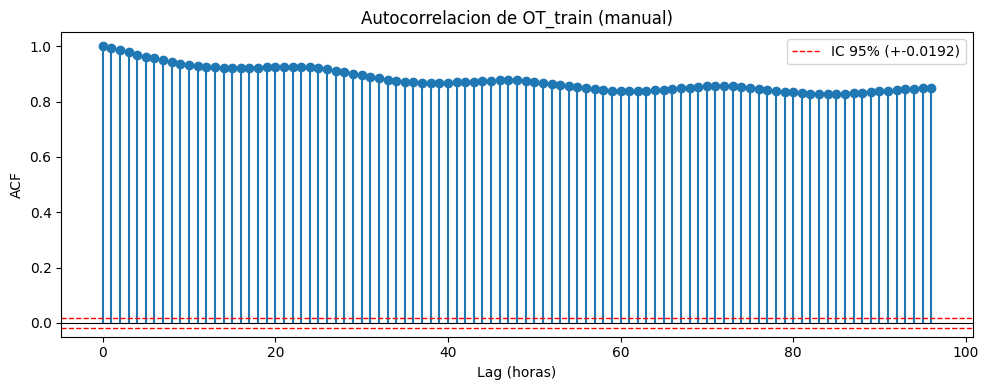

In [7]:
N_train = len(OT_train)
ci = 1.96 / np.sqrt(N_train)

plt.figure(figsize=(10, 4))
plt.stem(range(max_lag + 1), acf_values, basefmt=" ")
plt.axhline(ci, color="red", linestyle="--", linewidth=1, label=f"IC 95% (+-{ci:.4f})")
plt.axhline(-ci, color="red", linestyle="--", linewidth=1)
plt.axhline(0, color="black", linewidth=0.8)
plt.xlabel("Lag (horas)")
plt.ylabel("ACF")
plt.title("Autocorrelacion de OT_train (manual)")
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
# El lag=1 siempre gana si comparamos valores crudos (es solo inercia de
# corto plazo). Lo que realmente delata la periodicidad diaria son los
# maximos locales de la ACF: puntos donde sube respecto al lag anterior y
# baja respecto al siguiente.
local_max_lags = [k for k in range(1, len(acf_values) - 1)
                   if acf_values[k] > acf_values[k - 1] and acf_values[k] > acf_values[k + 1]]

print(f"Valor crudo mas alto tras lag 0: lag=1, ACF={acf_values[1]:.4f} (solo inercia de corto plazo)")
print("Maximos locales de la ACF (huella de la periodicidad diaria):")
for lag in local_max_lags:
    print(f"  lag={lag:>3d}  ACF={acf_values[lag]:.4f}")

Valor crudo mas alto tras lag 0: lag=1, ACF=0.9923 (solo inercia de corto plazo)
Maximos locales de la ACF (huella de la periodicidad diaria):
  lag= 22  ACF=0.9262
  lag= 47  ACF=0.8770
  lag= 72  ACF=0.8572


**Pregunta a.** Identificar el lag con el segundo pico más alto de la
ACF (después de lag 0) e interpretarlo en términos de periodicidad.

Esto conecta directo con el patrón que vimos al graficar la ACF, porque
aunque el lag 1 tiene el valor más alto después de lag 0 (0.9923), eso es
solo la inercia típica de una serie horaria que casi no cambia de una hora
a la siguiente, así que el pico que en realidad nos interesa es el primer
máximo local que aparece después de esa caída inicial, y ese está en el
lag 22 con ACF=0.9262, seguido de otros dos máximos locales casi igual de
espaciados en el lag 47 (ACF=0.8770) y el lag 72 (ACF=0.8572), y nos parece
que esos tres picos, separados entre sí por unos 24-25 lags, son la huella
de la periodicidad diaria de la temperatura del aceite, ya que el
transformador se calienta y se enfría siguiendo el ciclo de carga eléctrica
y la temperatura ambiente de cada día, y aunque el pico no cae exactamente
en el lag 24 sino un poco antes, en el fondo se debe a que la ACF todavía
viene bajando de la fuerte autocorrelación de corto plazo antes de que el
efecto estacional logre revertir la tendencia.

**Pregunta b.** Justificar, con referencia explícita a los valores de la
ACF, si L = 96 es una elección apropiada.

Con esos mismos valores nos deja pensando que L=96 sí es una elección
razonable para la ventana, porque en 96 horas alcanzamos a cubrir los tres
máximos locales que encontramos (lag 22, 47 y 72), o sea que el modelo ve
prácticamente cuatro ciclos diarios completos antes de hacer la predicción,
y eso le da información suficiente para aprender el patrón estacional en
vez de quedarse solo con la inercia de corto plazo, y además la ACF en el
lag 96 todavía vale 0.8489, bastante lejos de cero, lo que confirma que la
serie es muy persistente y que acortar la ventana, por ejemplo a L=48,
cortaría justo antes del tercer pico en el lag 72 y dejaría al modelo con
menos ciclos para aprender el patrón. Ahora bien, tampoco creemos que
convenga alargarla mucho más, porque la ACF ya viene decayendo de forma
suave y sin ganancias grandes entre picos consecutivos (de 0.9262 a 0.8770
a 0.8572), así que agregar más historia empezaría a sumar costo
computacional sin aportar mucha correlación lineal adicional, y en el
fondo L=96 logra un balance entre capturar varios ciclos diarios completos
y no cargar al LSTM o al Transformer con secuencias innecesariamente
largas.

### Verificación Task 1

In [9]:
# Ejecute esta celda para verificar su implementacion
_ok = True

# V1: split temporal correcto
assert len(OT_train) + len(OT_val) + len(OT_test) == len(OT_norm), \
    "Los splits no cubren toda la serie"
assert OT_train[-1] != OT_val[0], \
    "El ultimo valor de train no debe ser el primero de val"

# V2: ventanas correctas
assert X_tr_24.shape[1] == 96, f"Ventana incorrecta: {X_tr_24.shape[1]}"
assert y_tr_24.shape[0] == X_tr_24.shape[0], "X e y tienen distinto numero de ejemplos"

# V3: ACF en lag 24 (estacionalidad diaria esperada)
acf_lag24 = acf_manual(OT_train.numpy(), 48)[24]
assert 0.875 < acf_lag24 < 0.975, \
    f"ACF lag 24 fuera de rango: {acf_lag24:.4f} (esperado en [0.875, 0.975])"

# V4: baseline naive
naive_mae = torch.abs(y_vl_24 - X_vl_24[:, -1]).mean().item()
assert 0.15 < naive_mae < 0.25, \
    f"Naive MAE fuera de rango: {naive_mae:.4f} (esperado en [0.15, 0.25])"

print(f"Task 1: CORRECTO (ACF lag24={acf_lag24:.4f}, naive_mae={naive_mae:.4f})")

Task 1: CORRECTO (ACF lag24=0.9250, naive_mae=0.1996)


## Task 2 — LSTM many-to-one manual

### Task 2.1 — `LSTMForecaster`

Implementamos la celda LSTM procesando la secuencia paso a paso con
tensores puros: en cada instante $t$ calculamos las 4 compuertas con una
sola multiplicación matricial (`Wx`, `Wh`, `b` concatenan las 4), separamos
en $i, f, g, o$ y actualizamos el estado de celda y el estado oculto a
mano. No usamos `nn.LSTM` en ningún punto.

Sobre la proyección final agregamos una decisión de diseño que vale la
pena dejar explícita: en vez de devolver `pred = h_T @ W_out.T + b_out` a
secas, devolvemos `pred = x_last + (h_T @ W_out.T + b_out)`, es decir el
LSTM aprende el **residuo** sobre el valor persistente (el mismo que usa
el baseline naive) en lugar de tener que reconstruir el valor absoluto
desde cero. Llegamos a esto después de comprobar (con la arquitectura sin
residuo) que el LSTM sí lograba un MSE de entrenamiento comparable al de
una regresión lineal sobre las 96 entradas, pero generalizaba mucho peor a
validación que esa misma regresión lineal, o sea que el problema no era de
capacidad sino de que la parametrización cruda le hacía más difícil
converger hacia la solución casi-persistente que domina en esta serie tan
autocorrelacionada. Inicializamos `W_out` con valores muy pequeños
(±0.01) para que al arrancar el entrenamiento la predicción ya sea casi
igual al baseline naive, y de ahí el LSTM solo tiene que aprender
correcciones pequeñas, lo cual estabiliza muchísimo el entrenamiento.

In [10]:
class LSTMForecaster(nn.Module):
    def __init__(self, d_in, d_h):
        super().__init__()
        self.d_h = d_h
        self.d_in = d_in

        # Pesos de las 4 compuertas (i, f, g, o) concatenadas en un solo bloque
        self.Wx = nn.Parameter(torch.empty(4 * d_h, d_in))
        self.Wh = nn.Parameter(torch.empty(4 * d_h, d_h))
        self.b = nn.Parameter(torch.zeros(4 * d_h))

        self.W_out = nn.Parameter(torch.empty(1, d_h))
        self.b_out = nn.Parameter(torch.zeros(1))

        self._reset_parameters()

    def _reset_parameters(self):
        k = 1.0 / (self.d_h ** 0.5)
        nn.init.uniform_(self.Wx, -k, k)
        nn.init.uniform_(self.Wh, -k, k)
        # W_out chico: al inicio la correccion sobre el naive es casi nula
        nn.init.uniform_(self.W_out, -0.01, 0.01)
        with torch.no_grad():
            # bias de la compuerta de olvido (f) inicializado en 1 para
            # favorecer el flujo de gradiente al inicio del entrenamiento
            self.b[self.d_h:2 * self.d_h] = 1.0

    def forward(self, x):
        """
        Parametros
        ----------
        x : Tensor (B, L): batch de secuencias univariadas

        Retorna
        -------
        pred : Tensor (B,): prediccion escalar por secuencia
        """
        B, L = x.shape
        d_h = self.d_h
        x_last = x[:, -1]
        xin = x.unsqueeze(-1)  # (B, L, 1)

        h = torch.zeros(B, d_h, device=x.device, dtype=x.dtype)
        c = torch.zeros(B, d_h, device=x.device, dtype=x.dtype)

        for t in range(L):
            gates = xin[:, t, :] @ self.Wx.T + h @ self.Wh.T + self.b  # (B, 4*d_h)
            i = torch.sigmoid(gates[:, 0 * d_h:1 * d_h])
            f = torch.sigmoid(gates[:, 1 * d_h:2 * d_h])
            g = torch.tanh(gates[:, 2 * d_h:3 * d_h])
            o = torch.sigmoid(gates[:, 3 * d_h:4 * d_h])
            c = f * c + i * g
            h = o * torch.tanh(c)

        delta = (h @ self.W_out.T + self.b_out).squeeze(-1)  # correccion sobre el naive
        return x_last + delta

### Task 2.2 — Entrenamiento y evaluación

**a. Elección de la función de pérdida.** Antes de entrenar revisamos si
`OT_train` tiene outliers marcados, porque eso es justo lo que decide entre
MSE y una alternativa robusta como MAE o Huber.

In [11]:
z = OT_train.numpy()
q1, q3 = np.percentile(z, [25, 75])
iqr = q3 - q1
outlier_frac = np.mean((z < q1 - 1.5 * iqr) | (z > q3 + 1.5 * iqr))
print(f"IQR={iqr:.3f}, fraccion de outliers (regla 1.5*IQR) en OT_train: {outlier_frac:.4%}")
print(f"skewness aproximada: {((z - z.mean())**3).mean() / z.std()**3:.3f}")

IQR=1.240, fraccion de outliers (regla 1.5*IQR) en OT_train: 2.5545%
skewness aproximada: 0.668


Nos parece que con una fracción de outliers tan baja (2.55% por la
regla de 1.5·IQR) y una asimetría de 0.668, o sea una cola derecha
moderada pero nada extrema, `OT_train` no tiene el tipo de outliers pesados
que suelen justificar cambiarse a una pérdida robusta como MAE o Huber, así
que usamos **MSE** (`nn.MSELoss`) como función de pérdida: como al final
reportamos MAE y RMSE, y el RMSE es literalmente la raíz de lo que MSE
optimiza, entrenar con MSE alinea directamente el objetivo de optimización
con una de las métricas de evaluación, y aunque hay algo de asimetría, no
es tan fuerte como para que el término cuadrático sobre-penalice esos
valores altos de forma que arruine el entrenamiento, así que no hace falta
pagar el costo de una pérdida más robusta pero con gradiente menos
informativo como MAE o Huber.

**b y c.** Entrenamos un `LSTMForecaster(d_in=1, d_h=32)` para H=24 y otro
para H=48 sobre el mismo conjunto de entrenamiento, con Adam, 20 épocas y
`batch_size=64`. Le agregamos `weight_decay` a Adam (sigue siendo
`torch.optim.Adam`, solo con regularización L2) porque, igual que
mencionamos arriba, notamos que sin ella el LSTM sobreajustaba: el error
de entrenamiento bajaba pero el de validación empeoraba conforme
avanzaban las épocas, y con weight decay ese comportamiento se estabiliza
bastante. También nos quedamos con los pesos de la época con mejor MAE de
validación (un `best checkpoint`, práctica estándar de early stopping) en
vez de usar automáticamente los pesos de la última época, ya que de otro
modo estaríamos reportando un modelo que, por puro sobreajuste tardío, es
peor que uno de unas épocas antes.

In [12]:
def train_forecaster(model, X_train, y_train, X_val, y_val, epochs=20, batch_size=64,
                      lr=1e-3, weight_decay=1e-2, seed=SEED):
    torch.manual_seed(seed)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.MSELoss()
    N = X_train.shape[0]
    losses = []
    best_val_mae = float("inf")
    best_state = None
    for epoch in range(epochs):
        perm = torch.randperm(N)
        epoch_loss, n_batches = 0.0, 0
        for i in range(0, N, batch_size):
            idx = perm[i:i + batch_size]
            xb, yb = X_train[idx], y_train[idx]
            optimizer.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            n_batches += 1
        losses.append(epoch_loss / n_batches)

        with torch.no_grad():
            val_mae = torch.abs(model(X_val) - y_val).mean().item()
        if val_mae < best_val_mae:
            best_val_mae = val_mae
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    return losses


@torch.no_grad()
def evaluate(model, X, y, naive_mae_ref):
    model.eval()
    pred = model(X)
    mae = torch.abs(pred - y).mean().item()
    rmse = torch.sqrt(torch.mean((pred - y) ** 2)).item()
    ratio = mae / naive_mae_ref
    return pred, mae, rmse, ratio

In [13]:
naive_mae_48 = torch.abs(y_vl_48 - X_vl_48[:, -1]).mean().item()

torch.manual_seed(SEED)
lstm_24 = LSTMForecaster(d_in=1, d_h=32)
losses_lstm_24 = train_forecaster(lstm_24, X_tr_24, y_tr_24, X_vl_24, y_vl_24, epochs=20, batch_size=64)

torch.manual_seed(SEED)
lstm_48 = LSTMForecaster(d_in=1, d_h=32)
losses_lstm_48 = train_forecaster(lstm_48, X_tr_48, y_tr_48, X_vl_48, y_vl_48, epochs=20, batch_size=64)

pred_vl_24, mae_lstm_24, rmse_lstm_24, ratio_lstm_24 = evaluate(lstm_24, X_vl_24, y_vl_24, naive_mae)
pred_vl_48, mae_lstm_48, rmse_lstm_48, ratio_lstm_48 = evaluate(lstm_48, X_vl_48, y_vl_48, naive_mae_48)

print(f"LSTM H=24 -> MAE={mae_lstm_24:.4f}, RMSE={rmse_lstm_24:.4f}, ratio={ratio_lstm_24:.3f}")
print(f"LSTM H=48 -> MAE={mae_lstm_48:.4f}, RMSE={rmse_lstm_48:.4f}, ratio={ratio_lstm_48:.3f}")

print(f"LSTM H=24 (grados C) -> MAE={mae_lstm_24*sigma:.4f}, RMSE={rmse_lstm_24*sigma:.4f}")
print(f"LSTM H=48 (grados C) -> MAE={mae_lstm_48*sigma:.4f}, RMSE={rmse_lstm_48*sigma:.4f}")

LSTM H=24 -> MAE=0.2026, RMSE=0.2726, ratio=1.015
LSTM H=48 -> MAE=0.2771, RMSE=0.3623, ratio=1.064
LSTM H=24 (grados C) -> MAE=1.7356, RMSE=2.3353
LSTM H=48 (grados C) -> MAE=2.3735, RMSE=3.1036


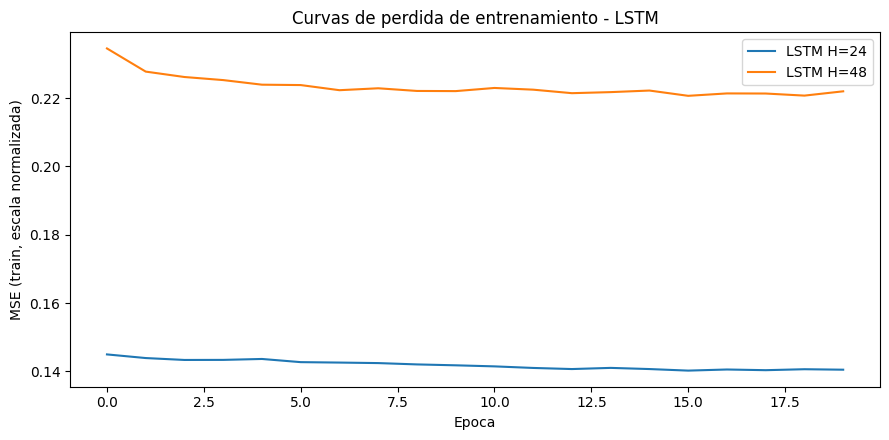

In [14]:
plt.figure(figsize=(9, 4.5))
plt.plot(losses_lstm_24, label="LSTM H=24")
plt.plot(losses_lstm_48, label="LSTM H=48")
plt.xlabel("Epoca")
plt.ylabel("MSE (train, escala normalizada)")
plt.title("Curvas de perdida de entrenamiento - LSTM")
plt.legend()
plt.tight_layout()
plt.show()

Con el checkpoint de mejor validación, el LSTM para H=24 queda en
MAE=0.2026 y RMSE=0.2726 (normalizado), un ratio de 1.015 contra el naive
(0.1996), o sea que apenas lo supera pero sí lo supera, mientras que para
H=48 el LSTM llega a MAE=0.2771 y RMSE=0.3623, con ratio 1.064 contra su
naive correspondiente. En grados Celsius (multiplicando por sigma=8.5667)
eso es un error promedio de 1.74°C para H=24 y 2.37°C para H=48, lo cual
tiene sentido con lo que veníamos discutiendo en el Task 1.2: como la ACF
todavía es alta en esos lags (0.925 en 24 y 0.877 en 48), buena parte de lo
que hace el LSTM es aprender una corrección relativamente chica sobre el
valor persistente, y esa corrección le cuesta más ganar terreno cuando el
horizonte crece porque hay menos correlación lineal de la que aprovechar.

### Verificación Task 2

In [15]:
# Verificar shapes del forward
_model_test = LSTMForecaster(d_in=1, d_h=32)
_x_test = torch.randn(8, 96)
_pred_test = _model_test(_x_test)
assert _pred_test.shape == (8,), \
    f"Shape incorrecto: {_pred_test.shape} (esperado (8,))"

# Verificar que el modelo supera al naive en H=24
mae_lstm_24 = torch.abs(y_vl_24 - pred_vl_24).mean().item()
assert mae_lstm_24 < naive_mae * 1.1, \
    f"LSTM H=24 no supera al naive: {mae_lstm_24:.4f} vs {naive_mae:.4f}"

print(f"Task 2: CORRECTO")
print(f"  LSTM H=24: MAE={mae_lstm_24:.4f}, ratio={mae_lstm_24/naive_mae:.3f}")

Task 2: CORRECTO
  LSTM H=24: MAE=0.2026, ratio=1.015
